Project root: /Users/mac/Desktop/DSS5104_Assignment2
Using device: cpu
PaySim features: 6
Features: ['is_high_risk_type', 'balance_diff_orig', 'orig_balance_zero', 'amt_to_balance_ratio', 'orig_tx_count', 'orig_amt_mean']

Train shape: (5090096, 17)
Test shape: (1272524, 17)
Train fraud rate: 0.000778
Test fraud rate: 0.003343

Original X_train shape: (5090096, 6)
Sampled to 100,000 samples for faster training
X_train shape after scaling: (100000, 6)
X_test shape after scaling: (1272524, 6)

Input dimension: 6
Speed settings: epochs=30, batch_size=8192, latent_dims=[8, 16]

Training: Semi-supervised VAE on PaySim
Semi-supervised mode: 99,917 normal samples

Training latent dimension 8 (1/2)
  Epoch 10/30, Loss: 11.4661, Val Loss: 3.0956
  Epoch 20/30, Loss: 13.2740, Val Loss: 2.7503
  Epoch 30/30, Loss: 4.1926, Val Loss: 2.6292

Training latent dimension 16 (2/2)
  Epoch 10/30, Loss: 130.0913, Val Loss: 3.2907
  Epoch 20/30, Loss: 8.3722, Val Loss: 2.8685
  Epoch 30/30, Loss: 6.1879, V

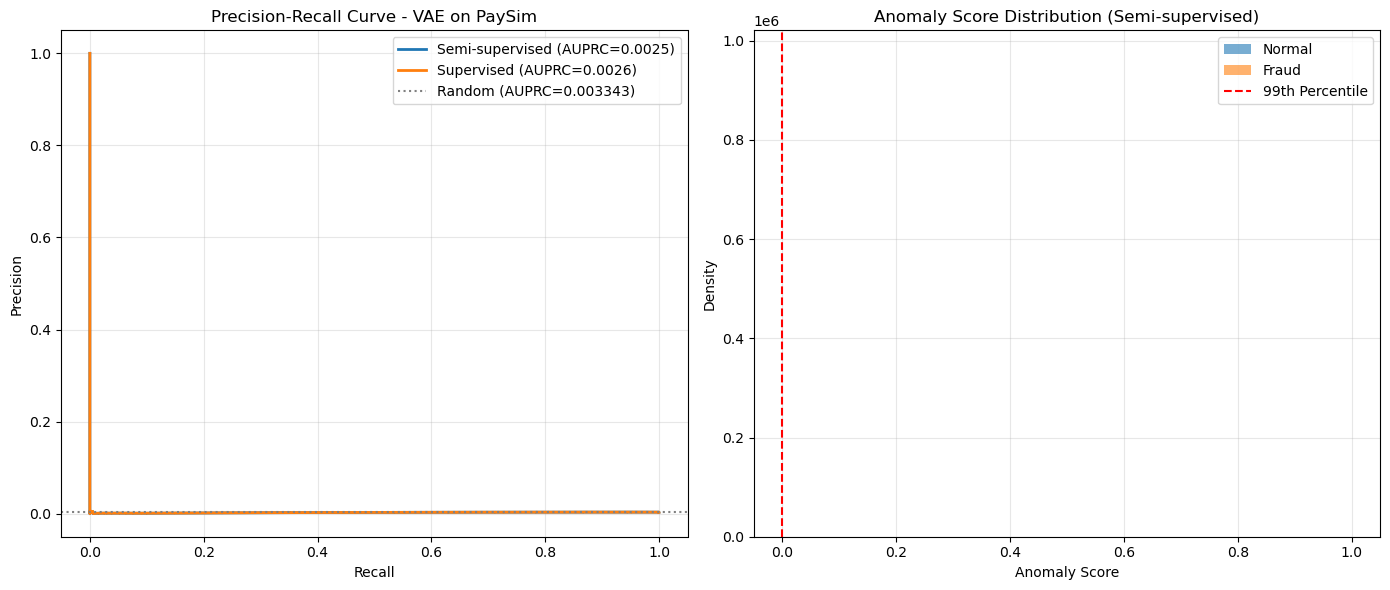


Results Summary - VAE on PaySim
              Model    AUPRC  ROC AUC Cost-Optimal Threshold Min Total Cost
Semi-supervised VAE 0.002543 0.406704                 0.0000  $2,125,328.00
     Supervised VAE 0.002584 0.415585                 0.0000  $2,125,392.00

✅ VAE on PaySim complete!


In [4]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)

# Set project root
try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_paysim_data():
    """Load PaySim data from processed folder"""
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    
    train = pd.read_parquet(data_dir / 'paysim_train.parquet')
    test = pd.read_parquet(data_dir / 'paysim_test.parquet')
    
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    
    features = info['paysim']['engineered_features']
    
    return train, test, features

# Load PaySim data
train_paysim, test_paysim, paysim_features = load_paysim_data()

print(f"PaySim features: {len(paysim_features)}")
print(f"Features: {paysim_features}")
print(f"\nTrain shape: {train_paysim.shape}")
print(f"Test shape: {test_paysim.shape}")
print(f"Train fraud rate: {train_paysim['isFraud'].mean():.6f}")
print(f"Test fraud rate: {test_paysim['isFraud'].mean():.6f}")

# 1. Feature Preparation (with sampling for speed)

X_train_raw = train_paysim[paysim_features].values
X_test_raw = test_paysim[paysim_features].values
y_train = train_paysim['isFraud'].values
y_test = test_paysim['isFraud'].values

print(f"\nOriginal X_train shape: {X_train_raw.shape}")

# Sample to reduce training time (use 100k samples)
SAMPLE_SIZE = 100000
if len(X_train_raw) > SAMPLE_SIZE:
    idx = np.random.choice(len(X_train_raw), SAMPLE_SIZE, replace=False)
    X_train_raw = X_train_raw[idx]
    y_train = y_train[idx]
    print(f"Sampled to {SAMPLE_SIZE:,} samples for faster training")

# Handle missing values
if np.isnan(X_train_raw).sum() > 0:
    print(f"Filling {np.isnan(X_train_raw).sum()} missing values...")
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape after scaling: {X_train.shape}")
print(f"X_test shape after scaling: {X_test.shape}")

# ============================================================
# 2. VAE Model (with NaN protection)
# ============================================================

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16, hidden_dims=[128, 64]):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h_dim))
            encoder_layers.append(nn.BatchNorm1d(h_dim))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        self.encoder = nn.Sequential(*encoder_layers)
        
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.fc_logvar = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Decoder
        decoder_layers = []
        prev_dim = latent_dim
        for h_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, h_dim))
            decoder_layers.append(nn.BatchNorm1d(h_dim))
            decoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        # Clamp logvar to prevent overflow
        logvar = torch.clamp(logvar, min=-10, max=10)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    
    def loss_function(self, recon, x, mu, logvar, beta=1.0):
        recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return (recon_loss + beta * kl_loss) / x.size(0)
    
    def get_anomaly_score(self, x, num_samples=10):
        self.eval()
        with torch.no_grad():
            mu, logvar = self.encode(x)
            # Clamp logvar
            logvar = torch.clamp(logvar, min=-10, max=10)
            
            recon_samples = []
            for _ in range(num_samples):
                z = self.reparameterize(mu, logvar)
                recon = self.decode(z)
                recon_samples.append(recon)
            recon_avg = torch.stack(recon_samples).mean(dim=0)
            
            # Add small epsilon to avoid numerical issues
            recon_error = ((x - recon_avg) ** 2).mean(dim=1) + 1e-8
            kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            kl_div = torch.clamp(kl_div, min=0, max=100)
            
            anomaly_score = recon_error + 0.1 * kl_div
            
            # Replace any NaN/Inf with valid values
            anomaly_score = torch.nan_to_num(anomaly_score, nan=1.0, posinf=1.0, neginf=0.0)
            
        return anomaly_score.cpu().numpy()


class EnsembleVAE:
    def __init__(self, input_dim, latent_dims=[8, 16]):
        self.input_dim = input_dim
        self.latent_dims = latent_dims
        self.models = []
    
    def _train_single(self, X_train, latent_dim, epochs=30, batch_size=8192, beta=1.0, verbose=True):
        val_size = int(len(X_train) * 0.1)
        X_train_sub = torch.FloatTensor(X_train[:-val_size]).to(device)
        X_val = torch.FloatTensor(X_train[-val_size:]).to(device)
        
        train_dataset = TensorDataset(X_train_sub, X_train_sub)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        model = VAE(self.input_dim, latent_dim=latent_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for batch_X, _ in train_loader:
                optimizer.zero_grad()
                recon, mu, logvar = model(batch_X)
                loss = model.loss_function(recon, batch_X, mu, logvar, beta=beta)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch_X.size(0)
            
            epoch_loss /= len(X_train_sub)
            
            model.eval()
            with torch.no_grad():
                recon, mu, logvar = model(X_val)
                val_loss = model.loss_function(recon, X_val, mu, logvar, beta=beta).item()
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = model.state_dict().copy()
            else:
                patience_counter += 1
            
            if patience_counter >= 10:
                break
            
            if verbose and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        model.load_state_dict(best_state)
        return model
    
    def fit(self, X_train, y_train, mode='semi_supervised', epochs=30, batch_size=8192, beta=1.0, verbose=True):
        if mode == 'semi_supervised':
            normal_idx = (y_train == 0)
            X_train_selected = X_train[normal_idx]
            print(f"Semi-supervised mode: {len(X_train_selected):,} normal samples")
        else:
            X_train_selected = X_train
            print(f"Supervised mode: {len(X_train_selected):,} all samples")
        
        self.models = []
        for i, lat_dim in enumerate(self.latent_dims):
            print(f"\nTraining latent dimension {lat_dim} ({i+1}/{len(self.latent_dims)})")
            model = self._train_single(X_train_selected, lat_dim, epochs, batch_size, beta, verbose)
            self.models.append(model)
        
        return self
    
    def predict_anomaly_scores(self, X, num_samples=5):
        X_tensor = torch.FloatTensor(X).to(device)
        all_scores = []
        for model in self.models:
            scores = model.get_anomaly_score(X_tensor, num_samples)
            all_scores.append(scores)
        scores = np.mean(all_scores, axis=0)
        
        # Handle any remaining NaN/Inf
        scores = np.nan_to_num(scores, nan=1.0, posinf=1.0, neginf=0.0)
        
        # Normalize to [0, 1]
        if scores.max() - scores.min() > 1e-8:
            scores = (scores - scores.min()) / (scores.max() - scores.min())
        else:
            scores = np.zeros_like(scores)
        
        return scores

# ============================================================
# 3. Train on PaySim
# ============================================================

input_dim = X_train.shape[1]
print(f"\nInput dimension: {input_dim}")

# Speed optimization parameters
EPOCHS = 30
BATCH_SIZE = 8192
LATENT_DIMS = [8, 16]

print(f"Speed settings: epochs={EPOCHS}, batch_size={BATCH_SIZE}, latent_dims={LATENT_DIMS}")

print("\n" + "="*60)
print("Training: Semi-supervised VAE on PaySim")
print("="*60)

vae_semi = EnsembleVAE(input_dim, latent_dims=LATENT_DIMS)
vae_semi.fit(X_train, y_train, mode='semi_supervised', epochs=EPOCHS, batch_size=BATCH_SIZE, beta=1.0, verbose=True)

test_scores_semi = vae_semi.predict_anomaly_scores(X_test, num_samples=5)

# Final NaN check
print(f"After prediction - NaN count: {np.isnan(test_scores_semi).sum()}, Inf count: {np.isinf(test_scores_semi).sum()}")
test_scores_semi = np.nan_to_num(test_scores_semi, nan=0.5, posinf=1.0, neginf=0.0)

auprc_semi = average_precision_score(y_test, test_scores_semi)
roc_auc_semi = roc_auc_score(y_test, test_scores_semi)

print(f"\nTest Results (Semi-supervised VAE on PaySim):")
print(f"  AUPRC: {auprc_semi:.4f}")
print(f"  ROC AUC: {roc_auc_semi:.4f}")

print("\n" + "="*60)
print("Training: Supervised VAE on PaySim")
print("="*60)

vae_sup = EnsembleVAE(input_dim, latent_dims=LATENT_DIMS)
vae_sup.fit(X_train, y_train, mode='supervised', epochs=EPOCHS, batch_size=BATCH_SIZE, beta=1.0, verbose=True)

test_scores_sup = vae_sup.predict_anomaly_scores(X_test, num_samples=5)

# Final NaN check
print(f"After prediction - NaN count: {np.isnan(test_scores_sup).sum()}, Inf count: {np.isinf(test_scores_sup).sum()}")
test_scores_sup = np.nan_to_num(test_scores_sup, nan=0.5, posinf=1.0, neginf=0.0)

auprc_sup = average_precision_score(y_test, test_scores_sup)
roc_auc_sup = roc_auc_score(y_test, test_scores_sup)

print(f"\nTest Results (Supervised VAE on PaySim):")
print(f"  AUPRC: {auprc_sup:.4f}")
print(f"  ROC AUC: {roc_auc_sup:.4f}")

# ============================================================
# 4. Cost-Sensitive Evaluation
# ============================================================

def normalize_scores(scores):
    if scores.max() - scores.min() > 1e-8:
        return (scores - scores.min()) / (scores.max() - scores.min())
    return scores

test_scores_semi_norm = normalize_scores(test_scores_semi)
test_scores_sup_norm = normalize_scores(test_scores_sup)

def find_cost_optimal_threshold(y_true, y_scores, fn_cost=500, fp_cost=2):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    costs = []
    f1_scores = []
    
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        total_cost = fn * fn_cost + fp * fp_cost
        costs.append(total_cost)
        p = tp / (tp + fp + 1e-9)
        r = tp / (tp + fn + 1e-9)
        f1_scores.append(2 * p * r / (p + r + 1e-9) if (p + r) > 0 else 0)
    
    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    min_cost = costs[best_idx]
    f1_best_idx = np.argmax(f1_scores)
    f1_optimal_threshold = thresholds[f1_best_idx]
    
    return best_threshold, min_cost, f1_optimal_threshold, thresholds, costs, f1_scores

cost_threshold_semi, min_cost_semi, f1_threshold_semi, thresholds_semi, costs_semi, f1_scores_semi = find_cost_optimal_threshold(
    y_test, test_scores_semi_norm, fn_cost=500, fp_cost=2
)

cost_threshold_sup, min_cost_sup, f1_threshold_sup, thresholds_sup, costs_sup, f1_scores_sup = find_cost_optimal_threshold(
    y_test, test_scores_sup_norm, fn_cost=500, fp_cost=2
)

print("\n" + "="*60)
print("Cost-Sensitive Evaluation on PaySim (FN=$500, FP=$2)")
print("="*60)
print(f"\nSemi-supervised VAE:")
print(f"  Cost-optimal threshold: {cost_threshold_semi:.4f}")
print(f"  F1-optimal threshold: {f1_threshold_semi:.4f}")
print(f"  Minimum total cost: ${min_cost_semi:,.2f}")

print(f"\nSupervised VAE:")
print(f"  Cost-optimal threshold: {cost_threshold_sup:.4f}")
print(f"  F1-optimal threshold: {f1_threshold_sup:.4f}")
print(f"  Minimum total cost: ${min_cost_sup:,.2f}")

# 5. Evaluation at Cost-Optimal Threshold

y_pred_semi = (test_scores_semi_norm > cost_threshold_semi).astype(int)
y_pred_sup = (test_scores_sup_norm > cost_threshold_sup).astype(int)

print("\n" + "="*60)
print(f"Evaluation at Cost-Optimal Threshold on PaySim")
print("="*60)

print(f"\nSemi-supervised VAE (threshold={cost_threshold_semi:.4f}):")
print(f"  AUPRC: {auprc_semi:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_semi):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_semi):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_semi):.4f}")

print(f"\nSupervised VAE (threshold={cost_threshold_sup:.4f}):")
print(f"  AUPRC: {auprc_sup:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_sup):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_sup):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_sup):.4f}")

# ============================================================
# 6. Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

precision_semi, recall_semi, _ = precision_recall_curve(y_test, test_scores_semi_norm)
precision_sup, recall_sup, _ = precision_recall_curve(y_test, test_scores_sup_norm)

axes[0].plot(recall_semi, precision_semi, linewidth=2, 
             label=f'Semi-supervised (AUPRC={auprc_semi:.4f})')
axes[0].plot(recall_sup, precision_sup, linewidth=2,
             label=f'Supervised (AUPRC={auprc_sup:.4f})')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
                label=f'Random (AUPRC={y_test.mean():.6f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - VAE on PaySim')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].hist(test_scores_semi[y_test==0], bins=50, alpha=0.6, label='Normal', density=True)
axes[1].hist(test_scores_semi[y_test==1], bins=50, alpha=0.6, label='Fraud', density=True)
threshold_99 = np.percentile(test_scores_semi[y_test==0], 99) if len(test_scores_semi[y_test==0]) > 0 else 0.5
axes[1].axvline(x=threshold_99, color='red', linestyle='--', label=f'99th Percentile')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Anomaly Score Distribution (Semi-supervised)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'vae_paysim_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. Save Results
# ============================================================

results_dir = PROJECT_ROOT / 'data/processed/dl_results'
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    'y_true': y_test,
    'vae_semi_score': test_scores_semi_norm,
    'vae_sup_score': test_scores_sup_norm
}).to_csv(results_dir / 'vae_scores_paysim.csv', index=False)

results_summary = pd.DataFrame({
    'Model': ['Semi-supervised VAE', 'Supervised VAE'],
    'AUPRC': [auprc_semi, auprc_sup],
    'ROC AUC': [roc_auc_semi, roc_auc_sup],
    'Cost-Optimal Threshold': [f"{cost_threshold_semi:.4f}", f"{cost_threshold_sup:.4f}"],
    'Min Total Cost': [f"${min_cost_semi:,.2f}", f"${min_cost_sup:,.2f}"]
})

print("\n" + "="*60)
print("Results Summary - VAE on PaySim")
print("="*60)
print(results_summary.to_string(index=False))

print("\n✅ VAE on PaySim complete!")